In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
#!uv pip install datasets
df = pd.read_parquet("hf://datasets/juliensimon/sentry-impact-risk/data/sentry_impact_risk.parquet")
df.head()

,last_observation,palermo_scale_cum,v_infinity_kms,impact_probability,n_potential_impacts,palermo_scale_max,diameter_km,last_observation_jd,absolute_magnitude,full_name,designation,torino_scale,year_range_min,year_range_max
0,2025-04-28,-0.93,14.100000,3.770000e-04,1,-0.93,1.300,2.460794e+06,17.94,29075 (1950 DA),29075,NaN,2880,2880
1,NaT,-1.40,5.991698,5.717000e-04,157,-1.58,0.490,2.459126e+06,20.63,101955 Bennu (1999 RQ36),101955,NaN,2178,2290
2,2008-05-09,-2.38,8.419012,1.658148e-04,44,-2.39,0.029,2.454596e+06,25.31,(2008 JL3),2008 JL3,0.0,2027,2122
3,1979-12-15,-2.69,23.760623,8.515158e-07,4,-2.99,0.660,2.444222e+06,18.54,(1979 XB),1979 XB,0.0,2056,2113
4,2000-10-03,-2.76,1.358027,2.743395e-03,300,-3.11,0.037,2.451820e+06,24.79,(2000 SG344),2000 SG344,0.0,2069,2122


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194 entries, 0 to 2193
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   last_observation     2193 non-null   datetime64[us]
 1   palermo_scale_cum    2194 non-null   float64       
 2   v_infinity_kms       2190 non-null   float64       
 3   impact_probability   2194 non-null   float64       
 4   n_potential_impacts  2194 non-null   int64         
 5   palermo_scale_max    2194 non-null   float64       
 6   diameter_km          2194 non-null   float64       
 7   last_observation_jd  2194 non-null   float64       
 8   absolute_magnitude   2194 non-null   float64       
 9   full_name            2194 non-null   object        
 10  designation          2194 non-null   object        
 11  torino_scale         2192 non-null   float64       
 12  year_range_min       2194 non-null   Int64         
 13  year_range_max       2194 non-nul

In [4]:
df.isna().sum()
#df.dropna()

last_observation       1
palermo_scale_cum      0
v_infinity_kms         4
impact_probability     0
n_potential_impacts    0
palermo_scale_max      0
diameter_km            0
last_observation_jd    0
absolute_magnitude     0
full_name              0
designation            0
torino_scale           2
year_range_min         0
year_range_max         0
dtype: int64

In [5]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Force CPU only
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_reg = df.copy()
df_reg = df_reg.dropna() 
df_reg['log_impact_probability'] = np.log10(df_reg['impact_probability'])

# Data loading and preprocessing
features = df.select_dtypes(include=['number']).columns.tolist()
features.remove('impact_probability')
X = df_reg[features]
y = df_reg['log_impact_probability']
scaler = StandardScaler()

X_processed = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

I0000 00:00:1788972113.844243  226097 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788972113.844845  226097 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788972113.903829  226097 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788972115.025581  226097 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [6]:
# Model definition
model = tf.keras.Sequential([
    layers.Input(shape=[len(X.keys())]),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

# Loss, optimizer, and metrics
optimizer = tf.keras.optimizers.Adam()#.RMSprop(0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae']) #metrics=['mae', 'mse']

# Training
model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=2)

# Evaluation
test_loss, test_mae = model.evaluate(X_test, y_test,batch_size=30, verbose=0)
print(f"Test MSE (Loss): {test_loss:.4f}")
print(f"Test MAE (Mean Absolute Error): {test_mae:.4f}")


E0000 00:00:1788972115.570985  226097 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/10
28/28 - 1s - 29ms/step - loss: 25.2376 - mae: 4.8338
Epoch 2/10
28/28 - 0s - 2ms/step - loss: 8.2166 - mae: 2.5114
Epoch 3/10
28/28 - 0s - 2ms/step - loss: 3.1190 - mae: 1.3214
Epoch 4/10
28/28 - 0s - 2ms/step - loss: 2.0647 - mae: 1.0789
Epoch 5/10
28/28 - 0s - 2ms/step - loss: 1.4672 - mae: 0.9279
Epoch 6/10
28/28 - 0s - 2ms/step - loss: 1.1045 - mae: 0.8143
Epoch 7/10
28/28 - 0s - 2ms/step - loss: 0.8608 - mae: 0.7217
Epoch 8/10
28/28 - 0s - 2ms/step - loss: 0.7011 - mae: 0.6553
Epoch 9/10
28/28 - 0s - 2ms/step - loss: 0.5861 - mae: 0.6001
Epoch 10/10
28/28 - 0s - 2ms/step - loss: 0.5065 - mae: 0.5581
Test MSE (Loss): 0.4528
Test MAE (Mean Absolute Error): 0.5340


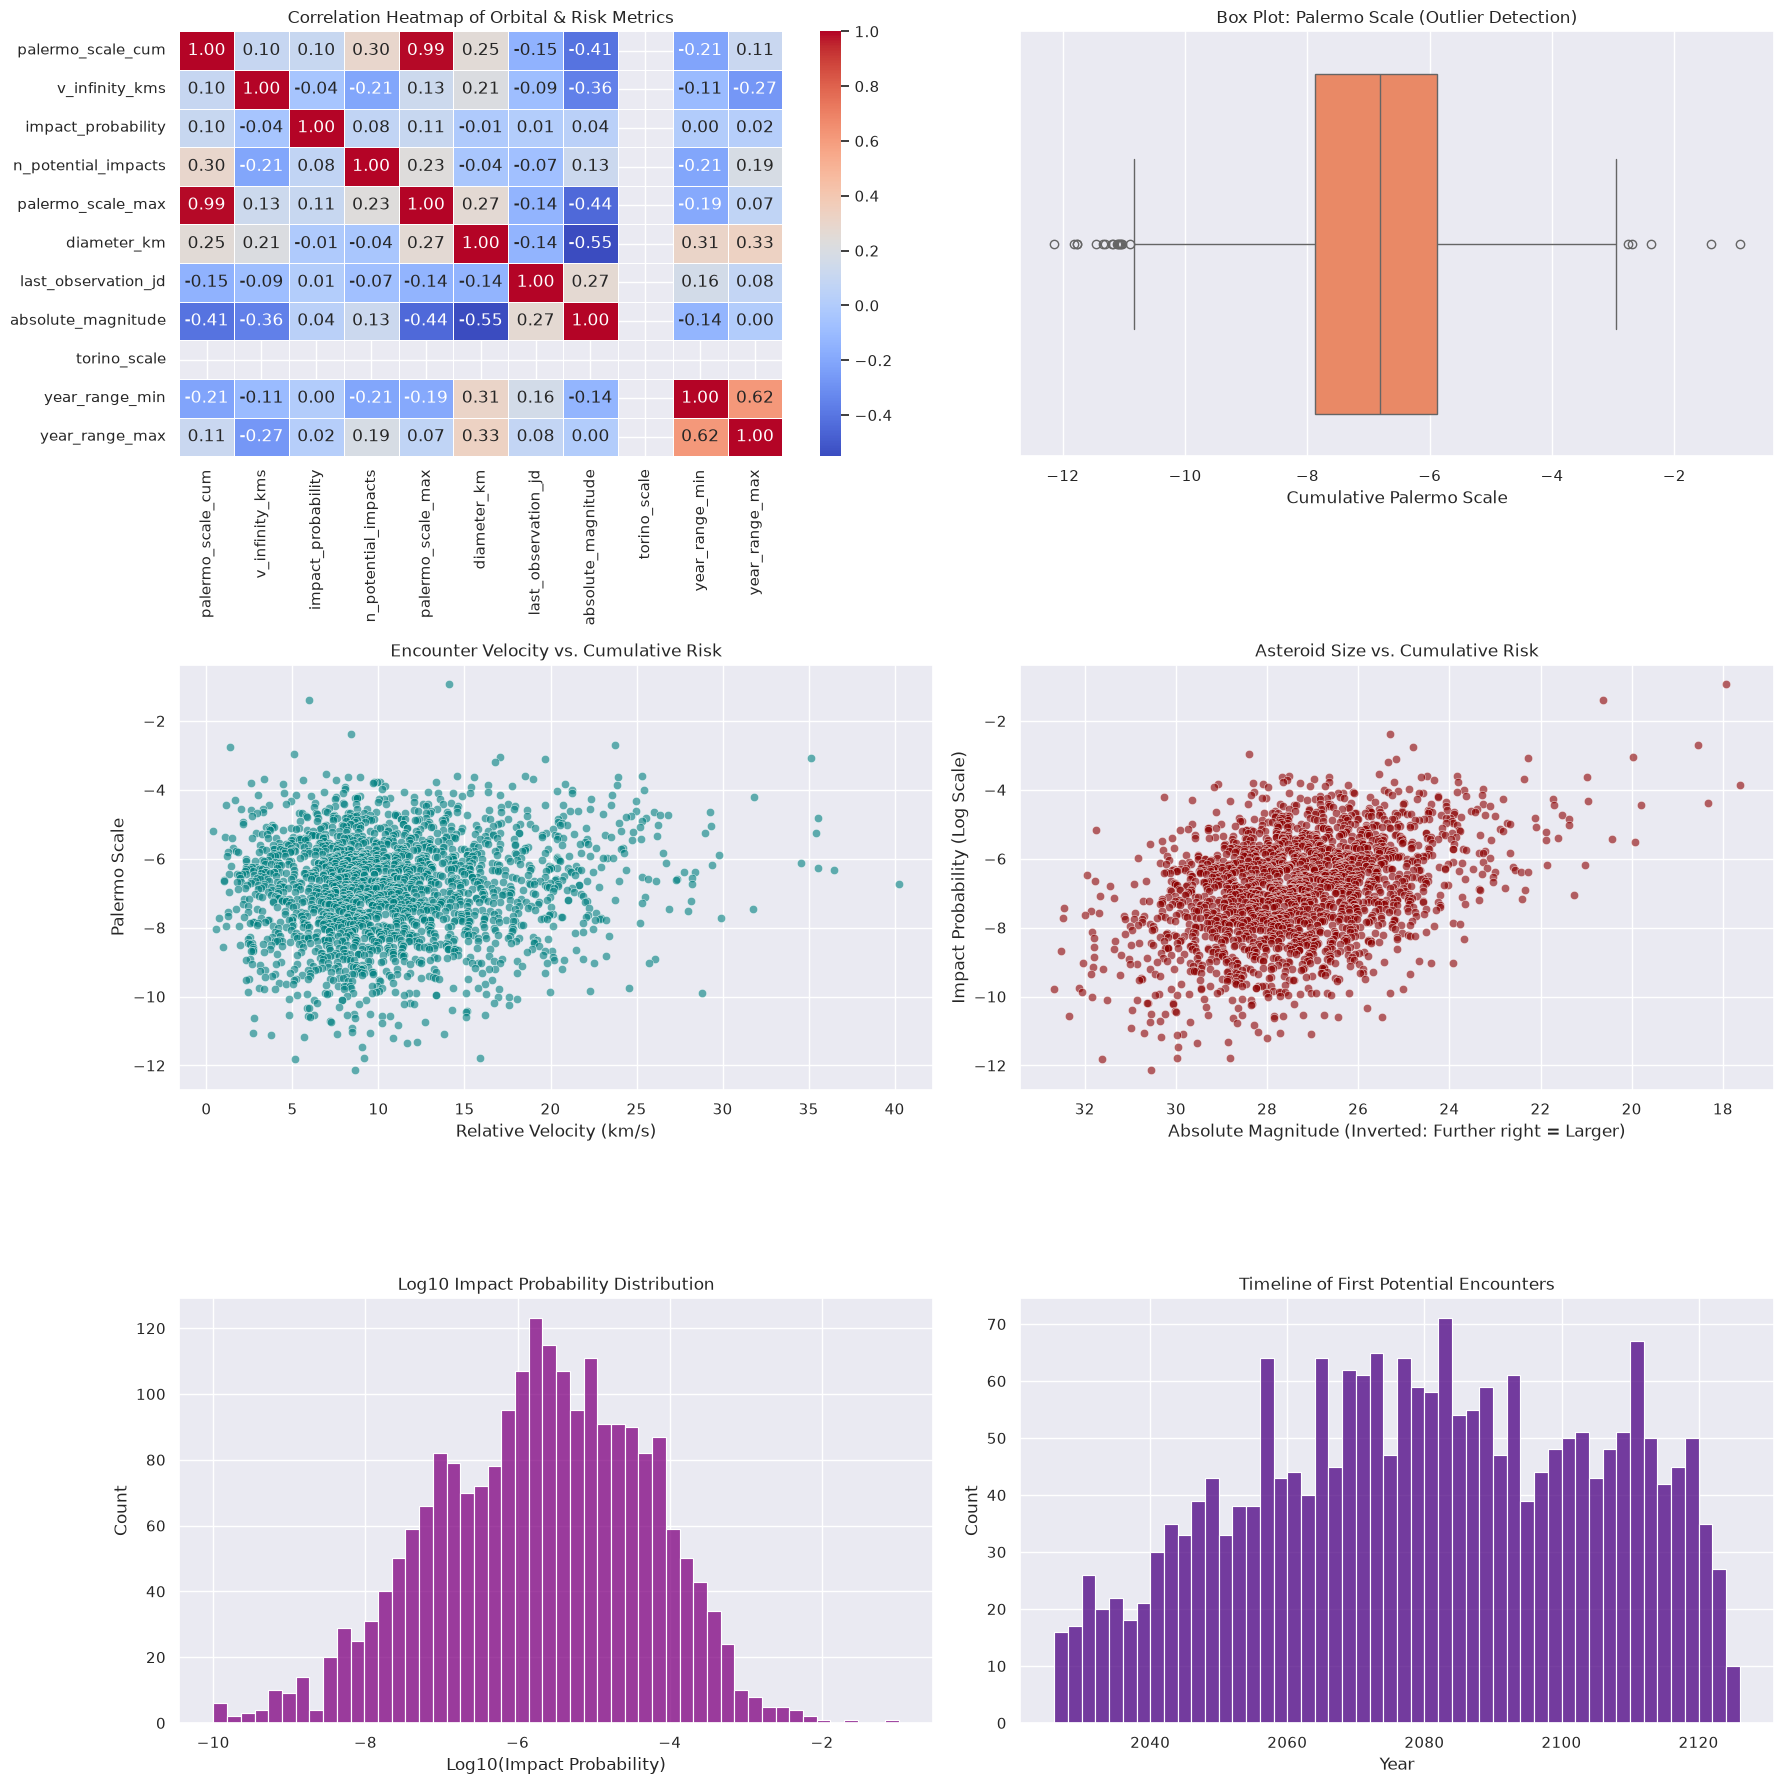

In [7]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Chart 1: Correlation Heatmap
# Select only numerical columns to find mathematical relationships
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap of Orbital & Risk Metrics')

sns.boxplot(x=df['palermo_scale_cum'], ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Box Plot: Palermo Scale (Outlier Detection)')
axes[0, 1].set_xlabel('Cumulative Palermo Scale')

sns.scatterplot(data=df, x='v_infinity_kms', y='palermo_scale_cum', 
                alpha=0.6, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Encounter Velocity vs. Cumulative Risk')
axes[1, 0].set_xlabel('Relative Velocity (km/s)')
axes[1, 0].set_ylabel('Palermo Scale')

#Chart 5: Scatter Plot - Size vs. Impact Probability
sns.scatterplot(data=df, x='absolute_magnitude', y='palermo_scale_cum', 
                alpha=0.6, ax=axes[1, 1], color='darkred')
axes[1, 1].invert_xaxis()
axes[1, 1].set_title('Asteroid Size vs. Cumulative Risk')
axes[1, 1].set_xlabel('Absolute Magnitude (Inverted: Further right = Larger)')
axes[1, 1].set_ylabel('Impact Probability (Log Scale)')

# Chart 4: Logarithmic Histogram - Impact Probability
# We apply log10 because probabilities are extremely small (e.g., 0.00001)
sns.histplot(df['impact_probability'].apply(np.log10), bins=50, ax=axes[2, 0], color='purple')
axes[2, 0].set_title('Log10 Impact Probability Distribution')
axes[2, 0].set_xlabel('Log10(Impact Probability)')


# Chart 6: Histogram - Timeline of Risks
sns.histplot(df['year_range_min'].dropna(), bins=50, binrange=(2026, 2126), ax=axes[2, 1], color='indigo')
axes[2, 1].set_title('Timeline of First Potential Encounters')
axes[2, 1].set_xlabel('Year')

plt.tight_layout()
plt.show()